# Example 18: Unit Conversion with Pint

PyStrata supports [pint](https://pint.readthedocs.io/) for transparent unit
handling. You can pass `pint.Quantity` values to constructors and PyStrata
will automatically convert them to the expected internal units (SI: meters,
m/s, kN/m³, etc.).

This example demonstrates three equivalent ways to define the same site
profile:

1. **Plain floats** – values are assumed to be in PyStrata's internal
   (metric) units.
2. **Pint with metric units** – explicit metric `Quantity` objects.
3. **Pint with Imperial units** – values specified in feet, lb/ft³, etc.
   are converted on the fly.

All three approaches produce identical results, which we verify in
Section 4.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.testing import assert_allclose

import pystrata
from pystrata import ureg

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Common setup

Load the input motion and define the outputs that will be reused for every
calculation.

In [2]:
ts = pystrata.motion.TimeSeriesMotion.load_at2_file("data/NIS090.AT2")

freqs = np.logspace(-1, 2, num=500)

A small helper to create the output collection and run the analysis for a
given profile.

In [3]:
def run_analysis(profile):
    """Run a linear-elastic analysis and return the outputs."""
    calc = pystrata.propagation.LinearElasticCalculator()
    outputs = pystrata.output.OutputCollection(
        [
            pystrata.output.ResponseSpectrumOutput(
                freqs,
                pystrata.output.OutputLocation("outcrop", index=0),
                0.05,
            ),
            pystrata.output.ResponseSpectrumRatioOutput(
                freqs,
                pystrata.output.OutputLocation("outcrop", index=-1),
                pystrata.output.OutputLocation("outcrop", index=0),
                0.05,
            ),
        ]
    )
    calc(ts, profile, profile.location("outcrop", index=-1))
    outputs(calc)
    return outputs

---
## 1. Plain floats (no pint)

When no `Quantity` objects are used, values are assumed to be in PyStrata's
internal (SI / metric) units:

| Parameter   | Unit    |
|-------------|----------|
| `unit_wt`   | kN/m³   |
| `thickness` | m       |
| `shear_vel` | m/s     |
| `damping`   | decimal |

In [4]:
profile_float = pystrata.site.Profile(
    [
        pystrata.site.Layer(pystrata.site.SoilType("Soil", 18.0, None, 0.05), 30, 400),
        pystrata.site.Layer(pystrata.site.SoilType("Rock", 24.0, None, 0.01), 0, 1200),
    ]
)

outputs_float = run_analysis(profile_float)

---
## 2. Pint with metric units (no conversion needed)

Wrapping values in their metric `Quantity` makes units explicit. Because
the units already match the internal representation, no conversion is
performed – the magnitudes are simply extracted.

In [5]:
profile_metric = pystrata.site.Profile(
    [
        pystrata.site.Layer(
            pystrata.site.SoilType(
                "Soil",
                18.0 * ureg.kilonewton / ureg.meter**3,
                None,
                0.05,
            ),
            30 * ureg.meter,
            400 * ureg.meter / ureg.second,
        ),
        pystrata.site.Layer(
            pystrata.site.SoilType(
                "Rock",
                24.0 * ureg.kilonewton / ureg.meter**3,
                None,
                0.01,
            ),
            0 * ureg.meter,
            1200 * ureg.meter / ureg.second,
        ),
    ]
)

outputs_metric = run_analysis(profile_metric)

---
## 3. Pint with Imperial units (conversion applied)

Here we specify every value in Imperial units. PyStrata automatically
converts them to the internal metric units before running the analysis.

The equivalent Imperial values were obtained by converting the metric
values used above:

In [6]:
# Show the conversions
print(
    "Unit weight: ",
    (18.0 * ureg.kilonewton / ureg.meter**3).to("force_pound / foot**3"),
)
print("Thickness:   ", (30.0 * ureg.meter).to("foot"))
print("Shear vel:   ", (400.0 * ureg.meter / ureg.second).to("foot / second"))
print()
print(
    "Unit weight: ",
    (24.0 * ureg.kilonewton / ureg.meter**3).to("force_pound / foot**3"),
)
print("Shear vel:   ", (1200.0 * ureg.meter / ureg.second).to("foot / second"))

Unit weight:  114.58584637675483 force_pound / foot ** 3
Thickness:    98.4251968503937 foot
Shear vel:    1312.3359580052493 foot / second

Unit weight:  152.78112850233978 force_pound / foot ** 3
Shear vel:    3937.0078740157483 foot / second


In [15]:
# Define unit weights in pounds-force per cubic foot
soil_unit_wt = (18.0 * ureg.kilonewton / ureg.meter**3).to("force_pound / foot**3")
rock_unit_wt = (24.0 * ureg.kilonewton / ureg.meter**3).to("force_pound / foot**3")

profile_imperial = pystrata.site.Profile(
    [
        pystrata.site.Layer(
            pystrata.site.SoilType("Soil", soil_unit_wt, None, 0.05),
            98.4252 * ureg.foot,
            1312.34 * ureg.foot / ureg.second,
        ),
        pystrata.site.Layer(
            pystrata.site.SoilType("Rock", rock_unit_wt, None, 0.01),
            0 * ureg.foot,
            3937.01 * ureg.foot / ureg.second,
        ),
    ]
)

outputs_imperial = run_analysis(profile_imperial)

Verify that the internally stored values match the metric profile:

In [8]:
for attr in ["unit_wt", "thickness", "initial_shear_vel"]:
    for i, (lf, li) in enumerate(zip(profile_float, profile_imperial)):
        val_f = getattr(lf, attr) if attr != "unit_wt" else lf.soil_type.unit_wt
        val_i = getattr(li, attr) if attr != "unit_wt" else li.soil_type.unit_wt
        print(f"Layer {i} {attr:20s}: float={val_f:.4f}  imperial={val_i:.4f}")

Layer 0 unit_wt             : float=18.0000  imperial=18.0000
Layer 1 unit_wt             : float=24.0000  imperial=24.0000
Layer 0 thickness           : float=30.0000  imperial=30.0000
Layer 1 thickness           : float=0.0000  imperial=0.0000
Layer 0 initial_shear_vel   : float=400.0000  imperial=400.0012
Layer 1 initial_shear_vel   : float=1200.0000  imperial=1200.0006


---
## 4. Comparison of results

All three calculations should produce identical (or nearly identical)
surface response spectra and spectral ratios.

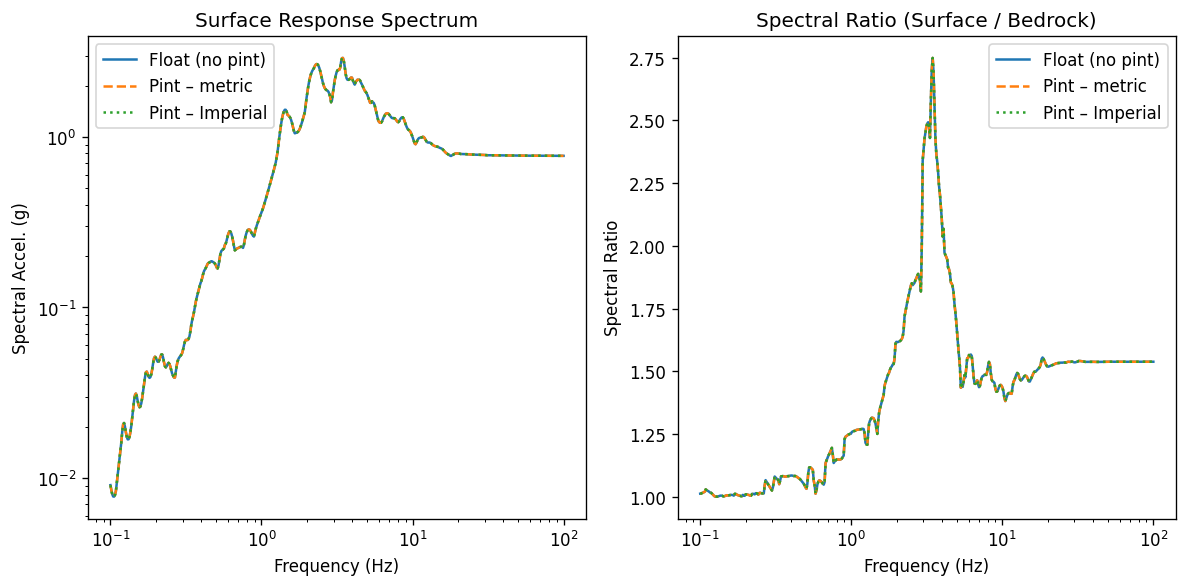

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ["Float (no pint)", "Pint – metric", "Pint – Imperial"]
linestyles = ["-", "--", ":"]
all_outputs = [outputs_float, outputs_metric, outputs_imperial]

# Response Spectra
ax = axes[0]
for label, ls, outs in zip(labels, linestyles, all_outputs):
    rs = outs[0]  # ResponseSpectrumOutput
    ax.plot(rs.freqs, rs.values, ls=ls, label=label)

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Spectral Accel. (g)",
    xscale="log",
    yscale="log",
    title="Surface Response Spectrum",
)
ax.legend()

# Spectral Ratios
ax = axes[1]
for label, ls, outs in zip(labels, linestyles, all_outputs):
    sr = outs[1]  # ResponseSpectrumRatioOutput
    ax.plot(sr.freqs, sr.values, ls=ls, label=label)

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Spectral Ratio",
    xscale="log",
    title="Spectral Ratio (Surface / Bedrock)",
)
ax.legend()

fig.tight_layout()

### Numerical verification

Confirm the results are within floating-point tolerance:

In [ ]:
# Compare response spectra
assert_allclose(
    outputs_float[0].values,
    outputs_metric[0].values,
    rtol=1e-10,
)
assert_allclose(
    outputs_float[0].values,
    outputs_imperial[0].values,
    rtol=1e-4,
)

# Compare spectral ratios
assert_allclose(
    outputs_float[1].values,
    outputs_metric[1].values,
    rtol=1e-10,
)
assert_allclose(
    outputs_float[1].values,
    outputs_imperial[1].values,
    rtol=1e-4,
)

print("All assertions passed – results are identical across unit systems.")

All assertions passed – results are identical across unit systems.
